# import library

In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

# Read CSV Data_set 

In [51]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# information about dataset 

'''
UID: unique identifier ranging from 1 to 10000

product ID: consisting of a letter L, M, or H for low (50% of all products), medium (30%) and high (20%) as product quality variants and a variant-specific serial number

type: just the product type L, M or H from column 2

air temperature [K]: generated using a random walk process later normalized to a standard deviation of 2 K around 300 K

process temperature [K]: generated using a random walk process normalized to a standard deviation of 1 K, added to the air temperature plus 10 K.

rotational speed [rpm]: calculated from a power of 2860 W, overlaid with a normally distributed noise

torque [Nm]: torque values are normally distributed around 40 Nm with a SD = 10 Nm and no negative values.

tool wear [min]: The quality variants H/M/L add 5/3/2 minutes of tool wear to the used tool in the process.

a 'machine failure' label that indicates, whether the machine has failed in this particular datapoint for any of the following failure
modes are true.

tool wear failure (TWF): the tool will be replaced of fail at a randomly selected tool wear time between 200 - 240 mins
(120 times in our dataset). At this point in time, the tool is replaced 69 times, and fails 51 times (randomly assigned).

heat dissipation failure (HDF): heat dissipation causes a process failure, if the difference between air- and process temperature 
is below 8.6 K and the tools rotational speed is below 1380 rpm. This is the case for 115 data points.

power failure (PWF): the product of torque and rotational speed (in rad/s) equals the power required for the process.
If this power is below 3500 W or above 9000 W, the process fails, which is the case 95 times in our dataset.

overstrain failure (OSF): if the product of tool wear and torque exceeds 11,000 minNm for the L product variant (12,000 M, 13,000 H),
the process fails due to overstrain. This is true for 98 datapoints.

random failures (RNF): each process has a chance of 0,1 % to fail regardless of its process parameters.
This is the case for only 5 datapoints, less than could be expected for 10,000 datapoints in our dataset.

If at least one of the above failure modes is true, the process fails and the 'machine failure' label is set to 1.
It is therefore not transparent to the machine learning method, which of the failure modes has caused the process to fail.
'''

In [52]:
df.shape

(10000, 14)

In [53]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [54]:
df.duplicated().sum()

np.int64(0)

In [55]:
df= df.drop(columns= "UDI")  

In [56]:
df.columns.tolist()

['Product ID',
 'Type',
 'Air temperature [K]',
 'Process temperature [K]',
 'Rotational speed [rpm]',
 'Torque [Nm]',
 'Tool wear [min]',
 'Machine failure',
 'TWF',
 'HDF',
 'PWF',
 'OSF',
 'RNF']

In [57]:
df.shape

(10000, 13)

In [58]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [59]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [60]:
df.head(3)

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0


In [61]:
df["Product ID"] = df["Product ID"].str[0]

print(df["Product ID"])

0       M
1       L
2       L
3       L
4       L
       ..
9995    M
9996    H
9997    M
9998    H
9999    M
Name: Product ID, Length: 10000, dtype: object


In [62]:
df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [63]:
df.groupby("Product ID").count()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
Product ID,,,,,,,,,,,,
H,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003
L,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
M,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997


In [64]:
df.groupby("Type").count()

,Product ID,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
Type,,,,,,,,,,,,
H,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003,1003
L,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000,6000
M,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997,2997


In [65]:
# here "Type" extract with "Product ID" so That's why I am deleting the Product ID.


In [66]:
df= df.drop(columns= "Product ID")

In [67]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# EDA

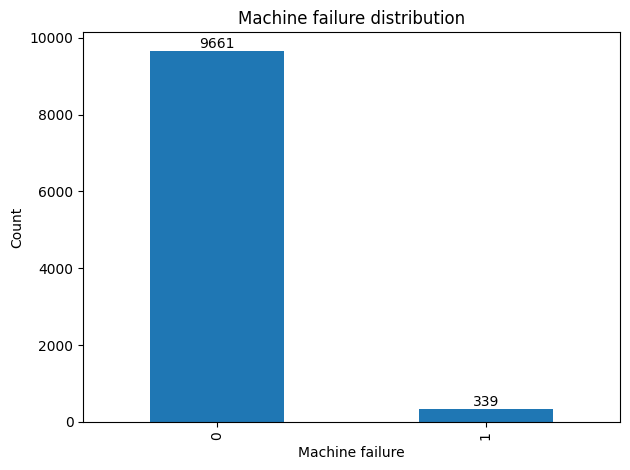

In [68]:
ax = df["Machine failure"].value_counts().plot(kind= 'bar')

plt.xlabel("Machine failure")
plt.ylabel("Count")
plt.title("Machine failure distribution")


for c in ax.containers:
    ax.bar_label(c)
    
plt.tight_layout()

      Machine failure
Type                 
H                1003
L                6000
M                2997


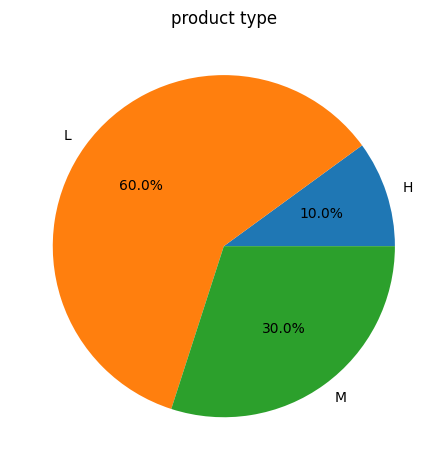

In [69]:
data = df.groupby("Type")["Machine failure"].count()

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%'   # Values percentage ke form me show hongi
)
plt.title("product type")
plt.tight_layout()
print(pd.DataFrame(data))

Type
False    4000
True     6000
Name: Machine failure, dtype: int64


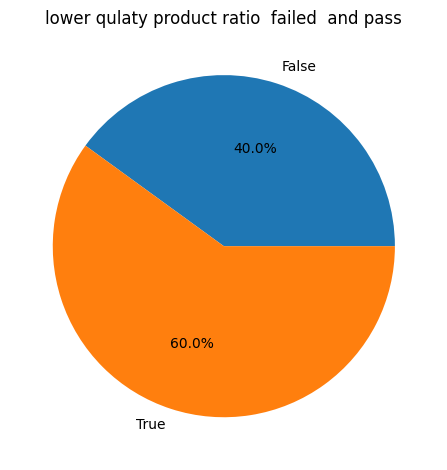

In [70]:
data_L= df.groupby(df["Type"] == "L")["Machine failure"].count()

plt.pie(
    data_L.values,
    labels=data_L.index,
    autopct='%1.1f%%'   # Values percentage ke form me show hongi
)
plt.title("lower qulaty product ratio  failed  and pass")
plt.tight_layout()

print(data_L)

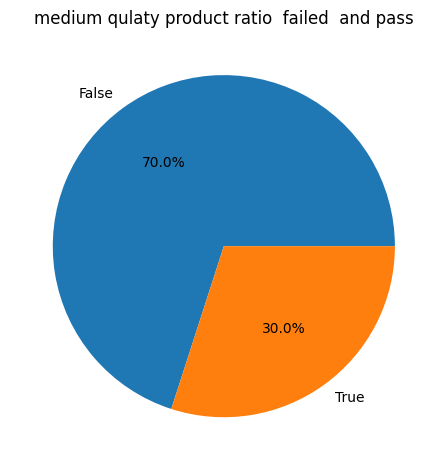

In [71]:
data_M= df.groupby(df["Type"] == "M")["Machine failure"].count()

plt.pie(
    data_M.values,
    labels=data_M.index,
    autopct='%1.1f%%'   # Values percentage ke form me show hongi
)
plt.title("medium qulaty product ratio  failed  and pass")
plt.tight_layout()

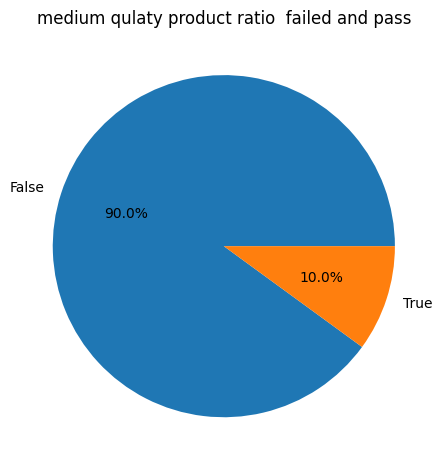

In [72]:
data_H= df.groupby(df["Type"] == "H")["Machine failure"].count()

plt.pie(
    data_H.values,
    labels=data_H.index,
    autopct='%1.1f%%'   # Values percentage ke form me show hongi
)
plt.title("medium qulaty product ratio  failed and pass")
plt.tight_layout()

Type  Machine failure
H     0                   982
      1                    21
L     0                  5765
      1                   235
M     0                  2914
      1                    83
Name: count, dtype: int64


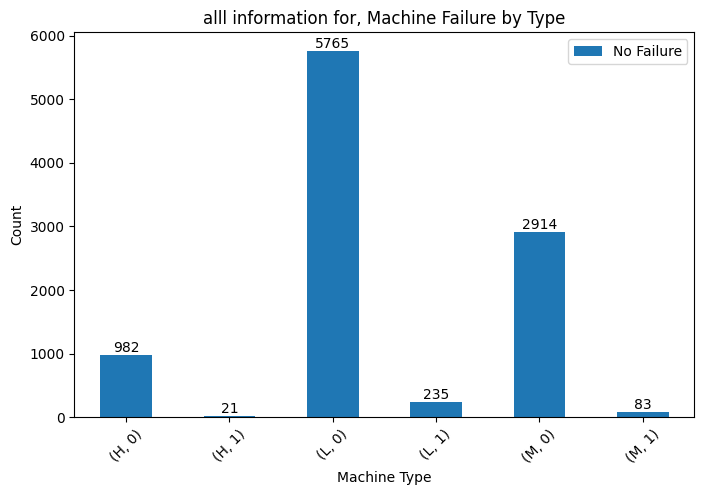

In [109]:
data= df.groupby("Type")["Machine failure"].value_counts()

ax= data.plot(kind="bar", figsize=(8, 5))

plt.title("alll information for, Machine Failure by Type")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["No Failure", "Failure"])

for c in ax.containers:
    ax.bar_label(c)

print(data)

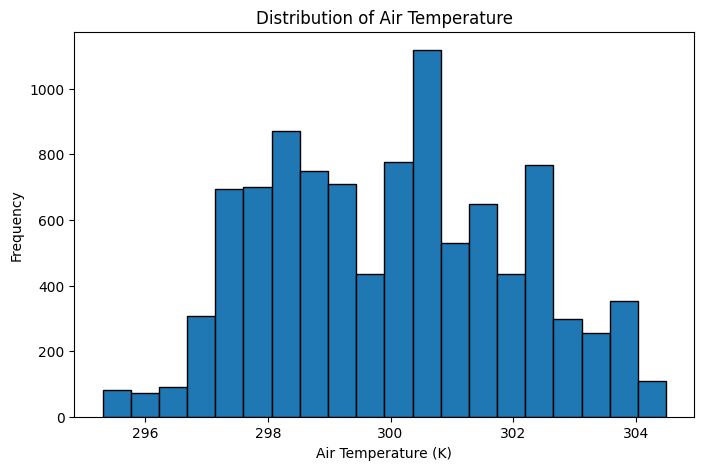

In [110]:
plt.figure(figsize=(8, 5))

plt.hist(df["Air temperature [K]"],
             bins=20,
             edgecolor="black")


plt.xlabel("Air Temperature (K)")
plt.ylabel("Frequency")
plt.title("Distribution of Air Temperature")
plt.show()

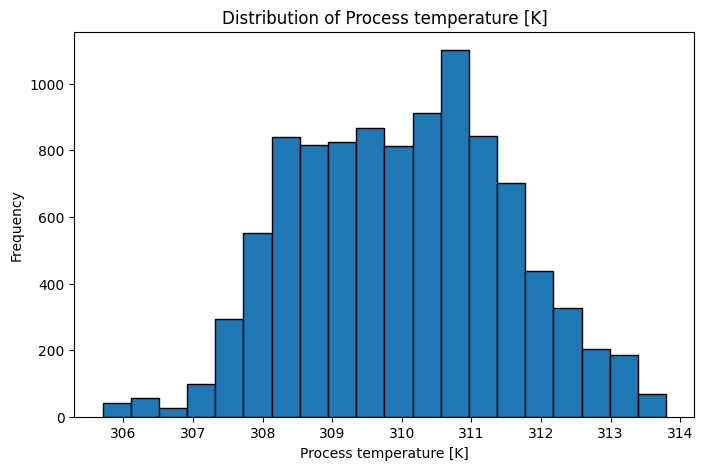

In [111]:
plt.figure(figsize=(8, 5))

plt.hist(df["Process temperature [K]"],
             bins=20,
             edgecolor="black")


plt.xlabel("Process temperature [K]")
plt.ylabel("Frequency")
plt.title("Distribution of Process temperature [K]")
plt.show()

In [112]:
plt.figure(figsize=(8,5))

plt.hist(df["Rotational speed [rpm]"],
        bins= 20,
        edgecolor= "black"
        )

plt.xlabel("["Rotational speed [rpm]")
plt.ylabel("Frequency")
plt.title("Distribution of Process Rotational speed [rpm]")


SyntaxError: unterminated string literal (detected at line 8) (2287491134.py, line 8)

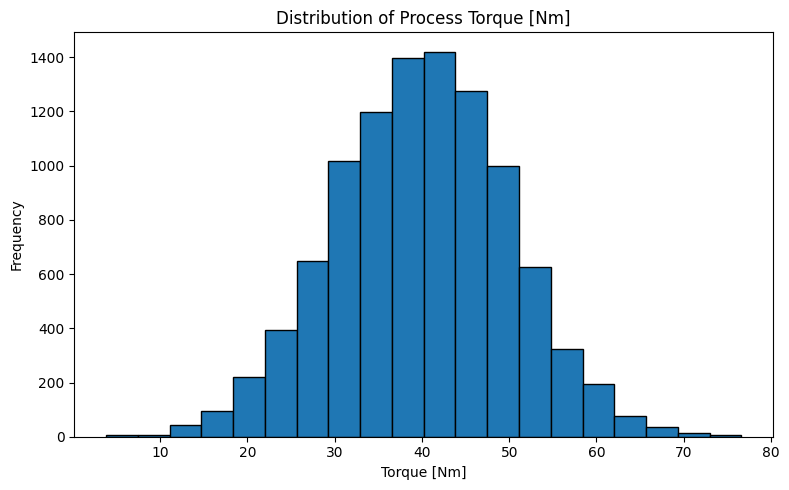

In [113]:
plt.figure(figsize=(8,5))

plt.hist(df["Torque [Nm]"],
        bins= 20,
        edgecolor= 'black'
)

plt.xlabel("Torque [Nm]")
plt.ylabel("Frequency")
plt.title("Distribution of Process Torque [Nm]")

plt.tight_layout()

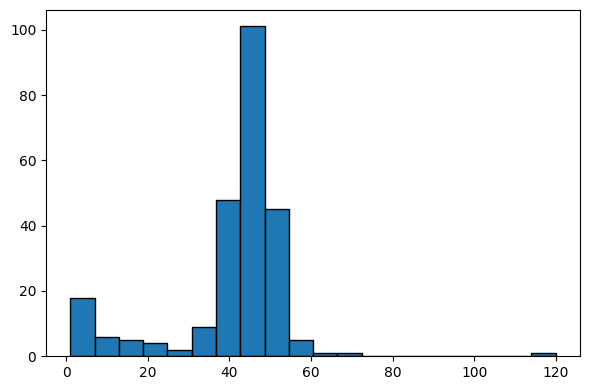

In [114]:
plt.figure(figsize= (6,4))


plt.hist(df["Tool wear [min]"].value_counts(),
         bins= 20,
         edgecolor= 'black'
        )

plt.tight_layout()

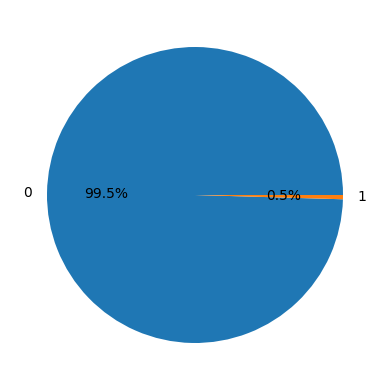

In [115]:
data= df["TWF"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
)

plt.title("")
plt.tight_layout()

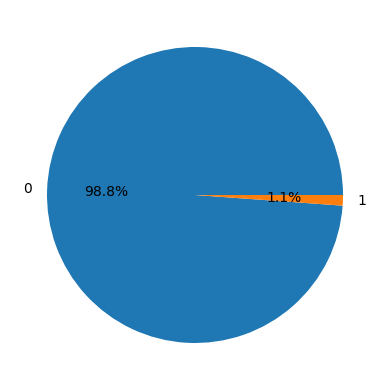

In [116]:
data= df["HDF"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
)

plt.title("")
plt.tight_layout()

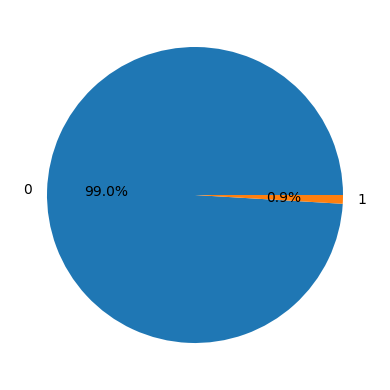

In [117]:
data= df["PWF"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
)

plt.title("")
plt.tight_layout()

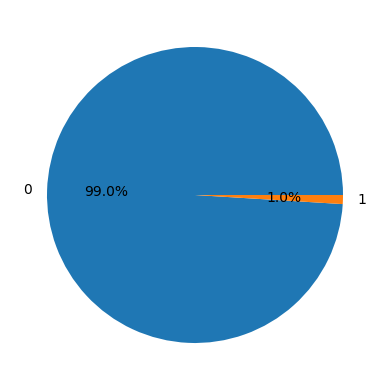

In [118]:
data= df["OSF"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
)

plt.title("")
plt.tight_layout()

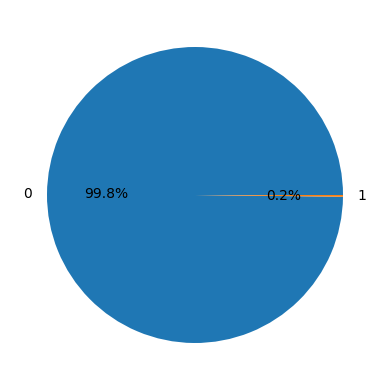

In [119]:
data= df["RNF"].value_counts()

plt.figure(figsize=(4,4))

plt.pie(
    data.values,
    labels=data.index,
    autopct='%1.1f%%',
)

plt.title("")
plt.tight_layout()

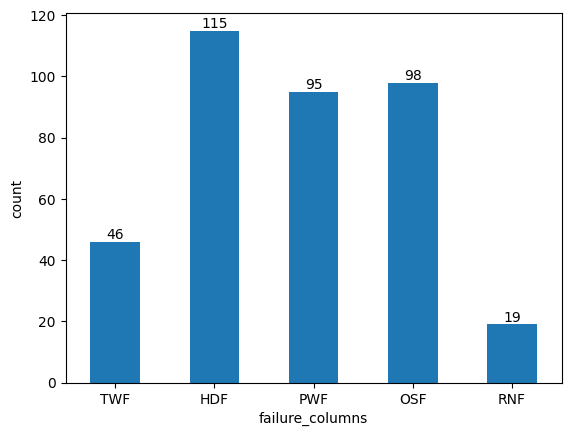

In [120]:
failure_cols = ["TWF","HDF","PWF","OSF","RNF"]

ax= df[failure_cols].sum().plot(kind="bar")

plt.xticks(rotation=0)
plt.xlabel("failure_columns")
plt.ylabel("count")

for c in ax.containers:
    ax.bar_label(c)

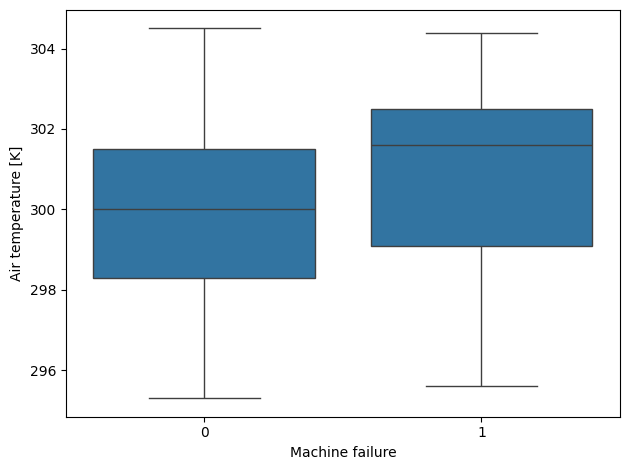

In [121]:
sns.boxplot(x="Machine failure",
            y="Air temperature [K]",
            data=df)

plt.tight_layout()

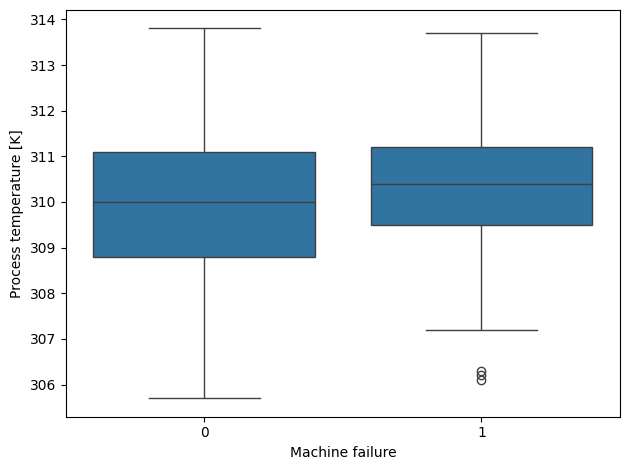

In [122]:
sns.boxplot(x="Machine failure",
            y="Process temperature [K]",
            data=df)

plt.tight_layout()

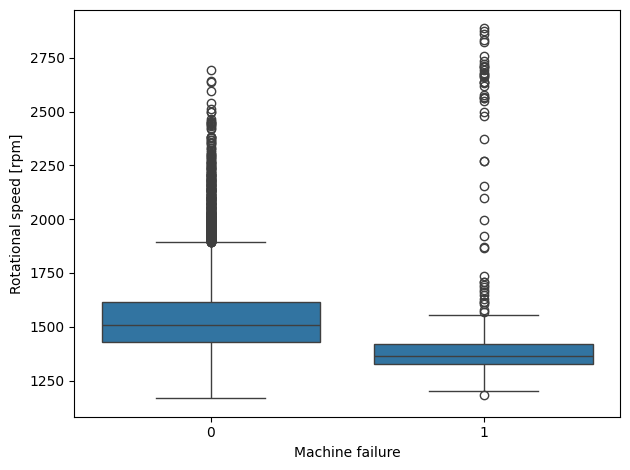

In [123]:
sns.boxplot(x="Machine failure",
            y="Rotational speed [rpm]",
            data=df)

plt.tight_layout()

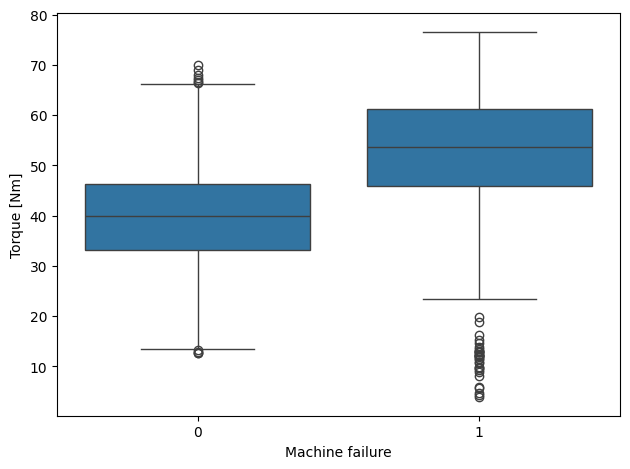

In [124]:
sns.boxplot(x="Machine failure",
            y="Torque [Nm]",
            data=df)

plt.tight_layout()

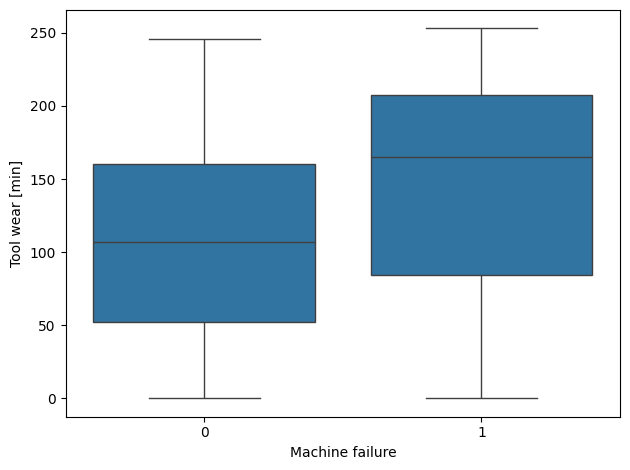

In [125]:
sns.boxplot(x="Machine failure",
            y="Tool wear [min]",
            data=df)

plt.tight_layout()

# Feature Engineering 

In [73]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [74]:
df["Temperature_diff"]= (
    df["Process temperature [K]"] - df["Air temperature [K]"]
)

In [75]:
omega= 2*np.pi*df["Rotational speed [rpm]"]/ 60

df["power"]= omega*df["Torque [Nm]"]

In [76]:
df["Wear_torque"]= (
    df["Tool wear [min]"]* df["Torque [Nm]"]
)

In [77]:
df["temperature_ratio"]= (
    df["Process temperature [K]"] / df["Air temperature [K]"]
)

In [78]:
df["torque_speed_ratio"]= (
    df["Torque [Nm]"] / df["Rotational speed [rpm]"]
)

In [79]:
df["wear_power_interaction"]= (
    df["Tool wear [min]"] * df["power"]
) 

In [80]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature_diff,power,Wear_torque,temperature_ratio,torque_speed_ratio,wear_power_interaction
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,6951.590560,0.0,1.035223,0.027595,0.000000
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,6826.722724,138.9,1.035211,0.032884,20480.168172
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,7749.387543,247.0,1.034888,0.032977,38746.937713
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,5927.504659,276.5,1.034876,0.027565,41492.532612
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,5897.816608,360.0,1.035211,0.028409,53080.349475


#  chack dtypes , and convert int64 to int16 and flot64 to flot32 

In [81]:
df.dtypes

Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
Temperature_diff           float64
power                      float64
Wear_torque                float64
temperature_ratio          float64
torque_speed_ratio         float64
wear_power_interaction     float64
dtype: object

In [99]:
data_int64= df.select_dtypes(include="int64").columns
data_float64= df.select_dtypes(include= "float64").columns

df[data_int64]= df[data_int64].astype('int16')
df[data_float64]= df[data_float64].astype('float32')

In [100]:
df.dtypes

Type                        object
Air temperature [K]        float32
Process temperature [K]    float32
Rotational speed [rpm]       int32
Torque [Nm]                float32
Tool wear [min]              int32
Machine failure              int32
TWF                          int32
HDF                          int32
PWF                          int32
OSF                          int32
RNF                          int32
Temperature_diff           float32
power                      float32
Wear_torque                float32
temperature_ratio          float32
torque_speed_ratio         float32
wear_power_interaction     float32
dtype: object

# import sklearn library 

In [101]:
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

In [102]:
SimpleImputer()
StandardScaler()
OneHotEncoder(handle_unknown="ignore")
RandomForestClassifier()

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

# split train aur test data set

In [103]:
drop_col= [
    "Machine failure",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF"
]

X= df.drop(columns= drop_col)

y= df["Machine failure"]

In [104]:
X.shape

(10000, 12)

In [105]:
y.shape

(10000,)

In [106]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2, stratify=y)

In [107]:
print(X_train.shape)
print(y_train.shape)

(8000, 12)
(8000,)


# data processing 

In [108]:
df.head(2)

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature_diff,power,Wear_torque,temperature_ratio,torque_speed_ratio,wear_power_interaction
0,M,298.100006,308.600006,1551,42.799999,0,0,0,0,0,0,0,10.5,6951.590332,0.000000,1.035223,0.027595,0.000000
1,L,298.200012,308.700012,1408,46.299999,3,0,0,0,0,0,0,10.5,6826.722656,138.899994,1.035211,0.032884,20480.167969


In [109]:
num_col= [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature_diff",
    "power",
    "Wear_torque",
    "temperature_ratio",
    "torque_speed_ratio",
    "wear_power_interaction"  
]

cat_col= ["Type"]

In [110]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [111]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_col),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_col)
])

# train model 

In [112]:
Model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=500
    ))
])

In [113]:
Model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [114]:
y_pred = Model.predict(X_test)

In [115]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 0.993
Accuracy: 99.30%


# The Model train has been sucessfully 

# import pickle 

In [117]:
import joblib

In [119]:
joblib.dump(Model, "Model.pkl")

['Model.pkl']